In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [6]:
#Step 1: Load the files
df = pd.read_csv("stat-stop-smok-serv-eng-2025-26-q4.csv")
fin = pd.read_csv("stat-stop-smok-serv-finance-eng-2025-26-q4.csv")

In [7]:
print(df.shape)
print(df.columns.tolist())
df.head()

(110188, 23)
['FinancialYear', 'Quarter', 'OrgType', 'OrgCode', 'OrgName', 'RegionCode', 'RegionName', 'Sex', 'MonitoringCategoryType', 'MonitoringCategory', 'Total referred', 'Recipients', 'Set quit date', 'Quit', 'Not quit', 'Not known', 'Quit CO', 'Unengaged quit', 'Quit (%)', 'Not quit (%)', 'Not known (%)', 'Quit CO (%)', 'Quit CO of quitters (%)']


,FinancialYear,Quarter,OrgType,OrgCode,OrgName,RegionCode,RegionName,Sex,MonitoringCategoryType,MonitoringCategory,...,Quit,Not quit,Not known,Quit CO,Unengaged quit,Quit (%),Not quit (%),Not known (%),Quit CO (%),Quit CO of quitters (%)
0,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,18-34,...,5019.0,2458.0,3110.0,1138.0,:,47.5,23.3,29.4,10.8,22.7
1,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,35-44,...,5930.0,3150.0,3280.0,1228.0,:,48.0,25.5,26.6,9.9,20.7
2,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,45-59,...,11542.0,5804.0,4864.0,2651.0,:,52.0,26.1,21.9,11.9,23.0
3,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,60 and over,...,10281.0,5173.0,3200.0,2518.0,:,55.1,27.7,17.2,13.5,24.5
4,2025-26,1,National,E92000001,England,E92000001,England,All persons,Age band,All ages,...,32870.0,16648.0,14506.0,7556.0,:,51.4,26.0,22.7,11.8,23.0


In [9]:
#shape of the data 
print(df["OrgType"].unique())
print(df["Quarter"].unique())
print(df["MonitoringCategoryType"].unique())

['National' 'LARegion' 'LA']
[1 2 3 4]
['Age band' 'Ethnicity' 'Ethnicity grouped' 'Sexual orientation'
 'Eligibility to free prescriptions' 'Socio-economic classification'
 'Pharmacotherapy received' 'Intervention type' 'Intervention setting'
 'Swap to stop' 'Pregnant women']


This file has more than one row per local authority per quarter. It breaks activity down by age, ethnicity, sex, and other categories. If you sum the whole file blindly, you'll count people several times over, once per breakdown. You need to know that before you write any aggregation.

NHS suppresses small counts with : or * instead of leaving a blank. That turns the whole column into text. pd.to_numeric with errors="coerce" converts real numbers properly and turns the suppressed markers into missing values, rather than silently making them 0 or breaking later .sum() calls. Check df["Total referred"].dtype before this step and it's object, not a number, which is the tell.

In [10]:
numeric_cols = ["Total referred", "Set quit date", "Quit", "Quit (%)"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes

Total referred    float64
Set quit date     float64
Quit              float64
Quit (%)          float64
dtype: object

In [11]:
base = df[
    (df["MonitoringCategoryType"] == "Age band") &
    (df["Sex"] == "All persons") &
    (df["MonitoringCategory"] == "All ages")
].copy()

base.shape

(652, 23)

## Build the West Sussex vs South East vs England trend

In [12]:
areas = ["West Sussex", "South East", "England"]
trend = base[base["OrgName"].isin(areas)][
    ["OrgName", "Quarter", "Total referred", "Set quit date", "Quit", "Quit (%)"]
].sort_values(["OrgName", "Quarter"])

trend

,OrgName,Quarter,Total referred,Set quit date,Quit,Quit (%)
4,England,1,94855.0,63984.0,32870.0,51.4
28,England,2,98017.0,61957.0,32566.0,52.6
52,England,3,96747.0,63585.0,33945.0,53.4
76,England,4,115334.0,75976.0,41681.0,54.9
268,South East,1,14444.0,9711.0,5051.0,52.0
484,South East,2,13231.0,9702.0,5112.0,52.7
700,South East,3,14925.0,9845.0,5151.0,52.3
916,South East,4,17495.0,11468.0,6035.0,52.6
4252,West Sussex,1,1060.0,893.0,401.0,44.9
7924,West Sussex,2,1014.0,892.0,388.0,43.5


### This gives a clean side-by-side view across the year, at three levels of geography, so you can see whether West Sussex is moving with, ahead of, or behind its region and the national picture.

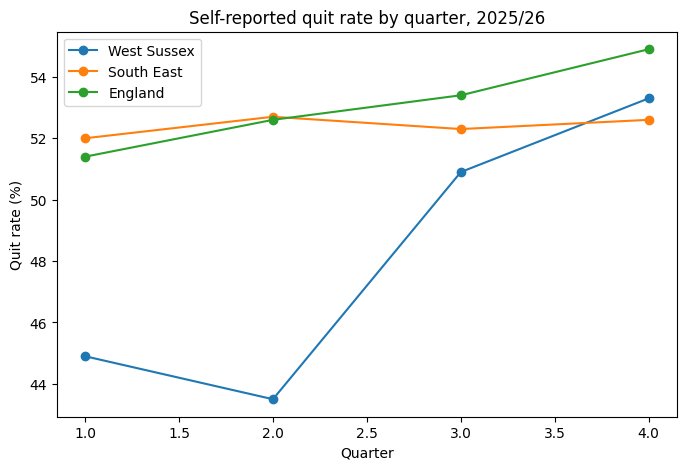

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for org in areas:
    sub = trend[trend["OrgName"] == org]
    ax.plot(sub["Quarter"], sub["Quit (%)"], marker="o", label=org)

ax.set_title("Self-reported quit rate by quarter, 2025/26")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quit rate (%)")
ax.legend()
plt.show()

### A quarterly line makes a within-year trend visible in a way a single annual number never can. This is what surfaced West Sussex's slow start and late recovery.

In [14]:
#Build the annual local authority comparison
se_las = base[(base["RegionName"] == "South East") & (base["OrgType"] == "LA")]

annual = se_las.groupby("OrgName").agg(
    quit_dates=("Set quit date", "sum"),
    quits=("Quit", "sum"),
).reset_index()

annual["quit_rate"] = (annual["quits"] / annual["quit_dates"] * 100).round(1)
annual = annual.sort_values("quit_rate", ascending=False)
annual

,OrgName,quit_dates,quits,quit_rate
18,Wokingham,701.0,456.0,65.0
15,West Berkshire,807.0,490.0,60.7
0,Bracknell Forest,1006.0,601.0,59.7
11,Reading,905.0,532.0,58.8
14,Surrey,3228.0,1896.0,58.7
3,East Sussex,2602.0,1511.0,58.1
9,Oxfordshire,1876.0,1082.0,57.7
17,Windsor and Maidenhead,803.0,460.0,57.3
6,Kent,7079.0,3896.0,55.0
4,Hampshire,5247.0,2811.0,53.6


### Summing all four quarters gives each local authority's full-year total.  This step only works correctly because Step 3 and Step 4 already fixed the numeric types and removed double-counting.

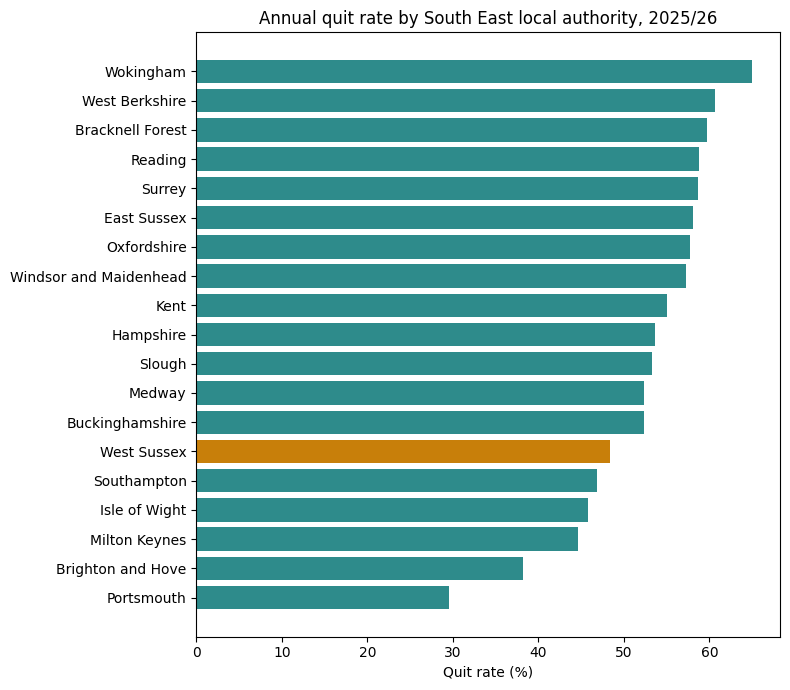

In [15]:
#Plot the local Authority tracking
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C87F0A" if la == "West Sussex" else "#2E8B8B" for la in annual["OrgName"]]
ax.barh(annual["OrgName"], annual["quit_rate"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Quit rate (%)")
ax.set_title("Annual quit rate by South East local authority, 2025/26")
plt.tight_layout()
plt.show()

a ranked bar chart shows where West Sussex sits against every peer at once, not just the regional average. Highlighting West Sussex in a different colour makes it easy to spot in a crowded chart.

In [17]:
#Bring in spend and calculate cost per quitter
fin_areas = fin[fin["OrgName"].isin(areas)].copy()
fin_areas["total_spend"] = (
    fin_areas["Total spend on delivery of stop smoking services for the year to date"]
    + fin_areas["Total cost of stop smoking aids for the year to date"]
)

annual_totals = base[base["OrgName"].isin(areas)].groupby("OrgName")["Quit"].sum().reset_index()
cost = annual_totals.merge(fin_areas[["OrgName", "total_spend"]], on="OrgName")
cost["cost_per_quitter"] = (cost["total_spend"] / cost["Quit"]).round(0)
cost

,OrgName,Quit,total_spend,cost_per_quitter
0,England,141062.0,99424791.0,705.0
1,South East,21349.0,15734400.0,737.0
2,West Sussex,1803.0,769944.0,427.0


the finance file is separate from the activity file, so it needs its own merge. Cost per quitter combines both files to answer a question the advert specifically asks about, spend against outcomes, rather than looking at quit rate alone.

In [18]:
trend.to_csv("west_sussex_vs_england_quarterly.csv", index=False)
annual.to_csv("local_authority_quit_rates.csv", index=False)
cost.to_csv("cost_per_quitter.csv", index=False)

In [20]:
# Reusable helper: gives one row per category (e.g. one row per
# socio-economic group) with quit rate calculated, for any area
# and any breakdown type in the file.
def annual_by_category(org_name, cat_type):
    sub = df[(df["OrgName"] == org_name)
             & (df["MonitoringCategoryType"] == cat_type)
             & (df["Sex"] == "All persons")]
    g = sub.groupby("MonitoringCategory").agg(
        quit_dates=("Set quit date", "sum"),
        quits=("Quit", "sum"),
    ).reset_index()
    g["quit_rate"] = (g["quits"] / g["quit_dates"] * 100).round(1)
    return g

### health inequalities: quit rate by socio-economic group

In [23]:
# This maps directly to the advert's stated priority: "reduce
# health inequalities." Compare West Sussex against England,
# group by group, rather than looking at one blended average.
ws_se = annual_by_category("West Sussex", "Socio-economic classification")
eng_se = annual_by_category("England", "Socio-economic classification")

se_gap = ws_se.merge(eng_se, on="MonitoringCategory", suffixes=("_WS", "_Eng"))
se_gap["gap_pts"] = (se_gap["quit_rate_WS"] - se_gap["quit_rate_Eng"]).round(1)

# Drop groups with very few quit attempts — a rate built on a
# handful of people is noise, not a finding.
se_gap = se_gap[se_gap["quit_dates_WS"] >= 30]
se_gap = se_gap.sort_values("quit_dates_WS", ascending=False)

se_gap.to_csv("socioeconomic_quit_rate_gap.csv", index=False)
se_gap[["MonitoringCategory", "quit_dates_WS", "quit_rate_WS", "quit_rate_Eng", "gap_pts"]]

,MonitoringCategory,quit_dates_WS,quit_rate_WS,quit_rate_Eng,gap_pts
7,Routine and manual occupations,791.0,44.9,56.6,-11.7
3,Managerial and professional occupations,621.0,55.9,56.2,-0.3
6,Retired,551.0,48.8,56.5,-7.7
8,Sick/disabled and unable to return to work,414.0,43.5,50.9,-7.4
9,Unable to code,410.0,53.2,47.3,5.9
4,Never worked or unemployed for over 1 year,393.0,36.1,47.8,-11.7
2,Intermediate occupations,376.0,57.2,56.4,0.8
1,Home carers (unpaid),129.0,45.7,53.0,-7.3
0,Full time students,42.0,40.5,46.2,-5.7


### routine and manual workers and the long-term unemployed trail England by 11.7 points each, and both are large groups (791 and 393 quit attempts), not small samples. Managerial and professional workers are almost level with England. 

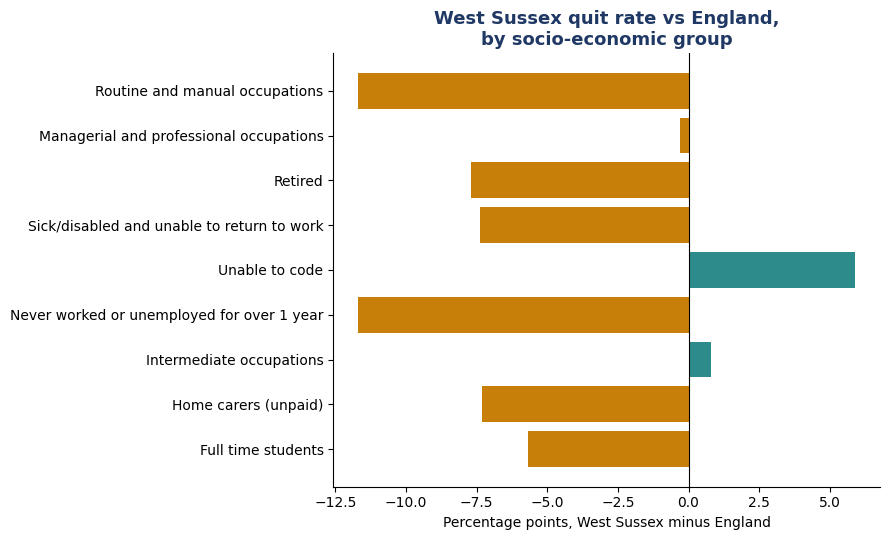

In [27]:
# Colour by direction, not category, so the eye goes straight to
# which groups are behind (amber) vs ahead (teal) of England.
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#C87F0A" if g < 0 else "#2E8B8B" for g in se_gap["gap_pts"]]
ax.barh(se_gap["MonitoringCategory"], se_gap["gap_pts"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)  # zero line marks "level with England"
ax.invert_yaxis()
ax.set_title("West Sussex quit rate vs England,\nby socio-economic group",
             fontsize=13, color="#1F3864", weight="bold")
ax.set_xlabel("Percentage points, West Sussex minus England")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("socioeconomic_quit_rate_gap.png", dpi=150)
plt.show()

## Which support type works: intervention type by quit rate

In [29]:
ws_it = annual_by_category("West Sussex", "Intervention type")
eng_it = annual_by_category("England", "Intervention type")

it_gap = ws_it.merge(eng_it, on="MonitoringCategory", suffixes=("_WS", "_Eng"))
it_gap["gap_pts"] = (it_gap["quit_rate_WS"] - it_gap["quit_rate_Eng"]).round(1)
it_gap = it_gap[it_gap["quit_dates_WS"] >= 30]
it_gap = it_gap.sort_values("quit_dates_WS", ascending=False)

it_gap.to_csv("intervention_type_quit_rate_gap.csv", index=False)
it_gap[["MonitoringCategory", "quit_dates_WS", "quit_rate_WS", "quit_rate_Eng", "gap_pts"]]

,MonitoringCategory,quit_dates_WS,quit_rate_WS,quit_rate_Eng,gap_pts
5,One-to-one support in person,1420.0,31.6,47.7,-16.1
2,Digital support by mobile application,974.0,54.9,47.8,7.1
8,Telephone support,634.0,63.9,56.5,7.4
0,Combination in-person & remote multi-session,411.0,53.0,58.4,-5.4
1,Combination one-to-one & mobile application mu...,249.0,75.9,50.1,25.8
3,Group support in person,34.0,17.6,49.5,-31.9


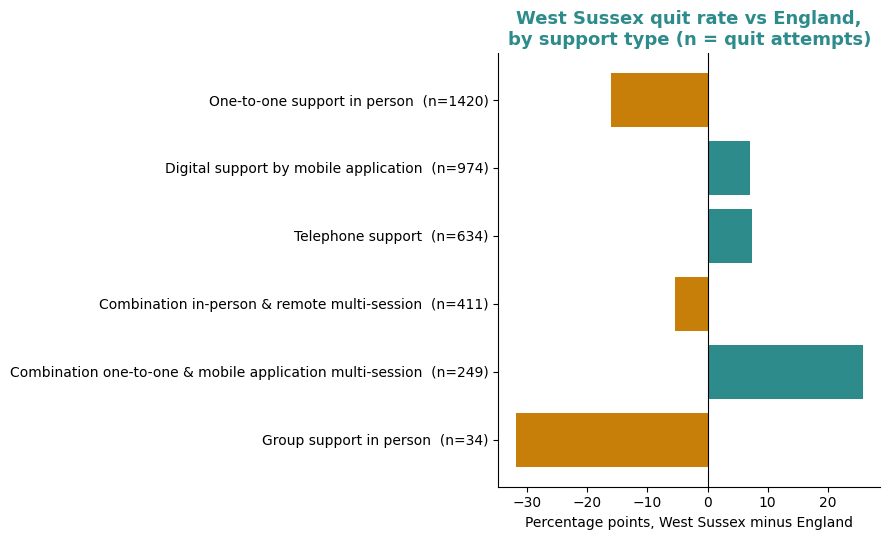

In [31]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#C87F0A" if g < 0 else "#2E8B8B" for g in it_gap["gap_pts"]]
labels = [f"{cat}  (n={int(n)})" for cat, n in zip(it_gap["MonitoringCategory"], it_gap["quit_dates_WS"])]
ax.barh(labels, it_gap["gap_pts"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Percentage points, West Sussex minus England")
ax.set_title("West Sussex quit rate vs England,\nby support type (n = quit attempts)",
             fontsize=13, color="#2E8B8B", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("intervention_type_quit_rate_gap.png", dpi=150)
plt.show()

#### one-to-one in-person support is West Sussex's highest-volume channel (1,420 quit attempts) and its weakest, 16.1 points behind England. Telephone and digital mobile-app support both beat England, but on far lower volumes. This is the single biggest lever visible in the data — it's both the largest channel and the largest shortfall.